In [2]:


import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

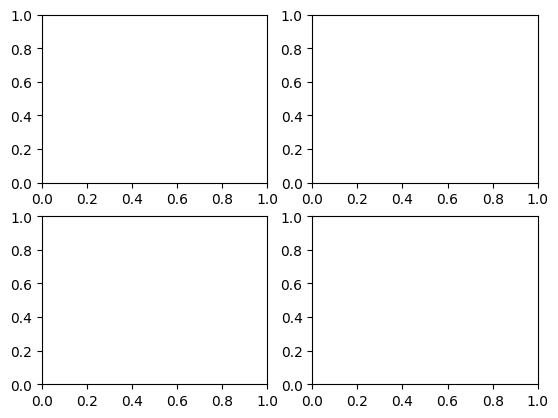

In [8]:
fig,ax=plt.subplots(2,2)

<Axes: xlabel='job_title_short'>

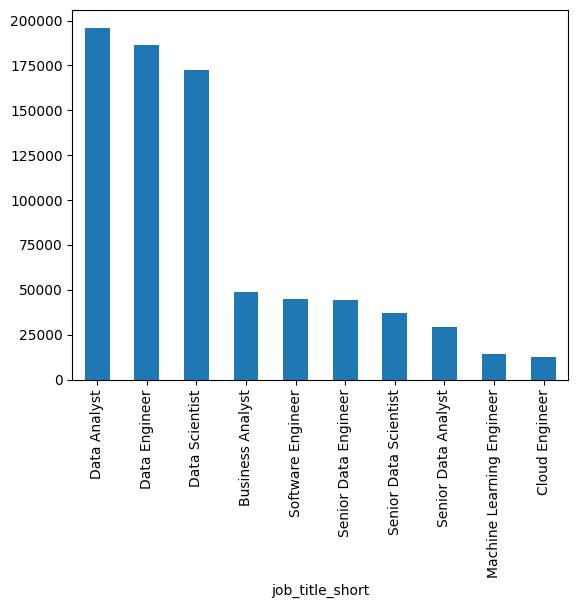

In [3]:
fig,ax=plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar',ax=ax)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

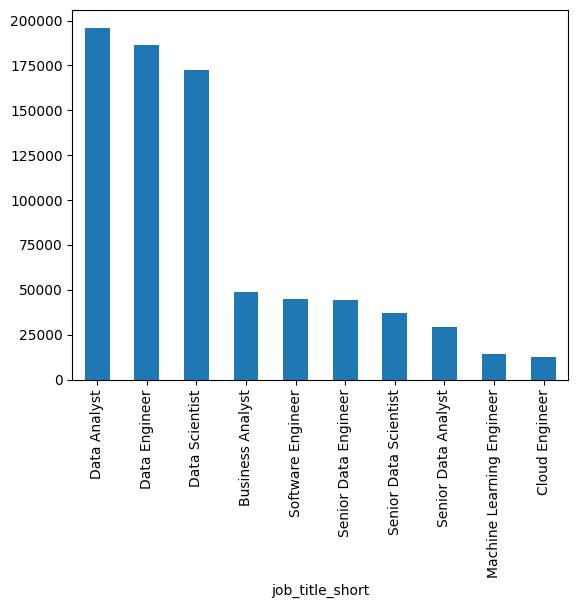

In [4]:
fig,ax=plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar',ax=ax)

df['job_schedule_type'].value_counts().head(3)

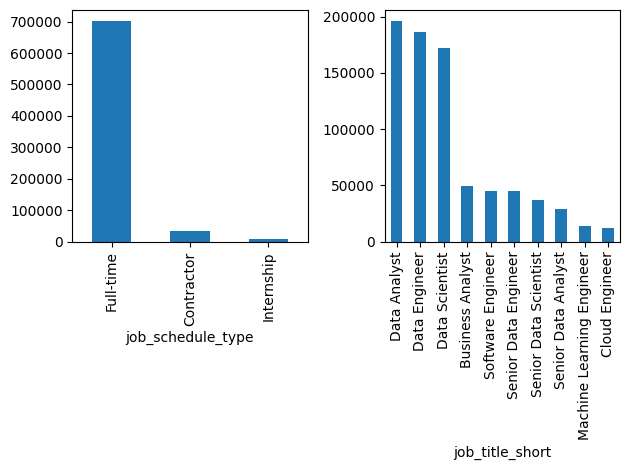

In [19]:
fig,ax=plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar',ax=ax[1])

df['job_schedule_type'].value_counts().head(3).plot(kind='bar',ax=ax[0])

fig.tight_layout()

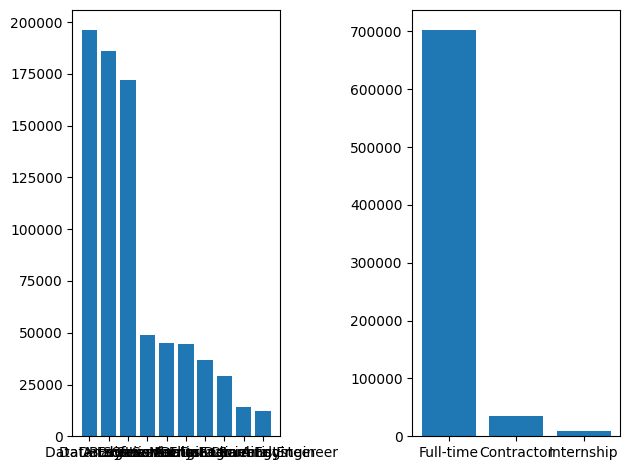

In [21]:
fig,ax=plt.subplots(1,2)

ax[0].bar(df['job_title_short'].value_counts().index,df['job_title_short'].value_counts())

ax[1].bar(df['job_schedule_type'].value_counts().head(3).index,df['job_schedule_type'].value_counts().head(3))

plt.tight_layout()

In [23]:
df_skills=df.copy()
df_skills=df_skills.explode('job_skills')
skills_count=df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count=skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


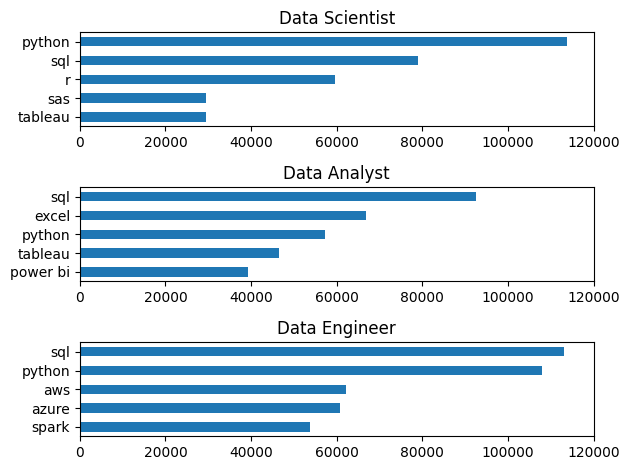

In [47]:
job_titles=['Data Scientist','Data Analyst','Data Engineer']



fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title) 
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120000)
    plt.tight_layout()
    
    

<span style ="color:green;font-width:bold; font-size:32px;"> Practice Prompts </span>

<Axes: xlabel='job_title'>

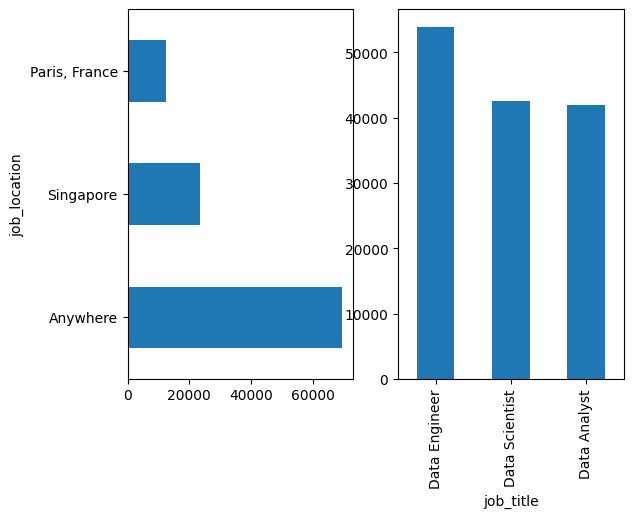

In [11]:
# Problem Statement:
# Create a subplot with 2 rows and 1 column:

# In the first subplot, plot a bar chart of the top 3 job locations by the number of job postings.
# In the second subplot, plot a horizontal bar chart of the top 3 job titles by the number of job postings.
# Use tight_layout() to adjust the spacing between subplots.
# Hint:
# Use plt.subplots() to create the subplots and fig.tight_layout() to adjust the spacing.

# fig,ax=plt.subplots(1,2)

# df['job_title_short'].value_counts().plot(kind='bar',ax=ax[1])

# df['job_schedule_type'].value_counts().head(3).plot(kind='bar',ax=ax[0])

fig,ax=plt.subplots(1,2)
df['job_location'].value_counts().head(3).plot(kind='barh',ax=ax[0])
df['job_title'].value_counts().head(3).plot(kind='bar',ax=ax[1])


# # # Create subplots

# # fig, ax = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# # First plot on ax[0]
# fig, ax = plt.subplots(1, 2)
# df['job_location'].value_counts().head(3).plot(kind='barh', ax=ax[0], color='skyblue')
# ax[0].set_title("Top 3 Job Locations")

# # Second plot on ax[1]
# df['job_title'].value_counts().head(3).plot(kind='bar', ax=ax[1], color='salmon')
# ax[1].set_title("Top 3 Job Titles")

# plt.tight_layout()  # Adjust layout for better visibility
# plt.show()



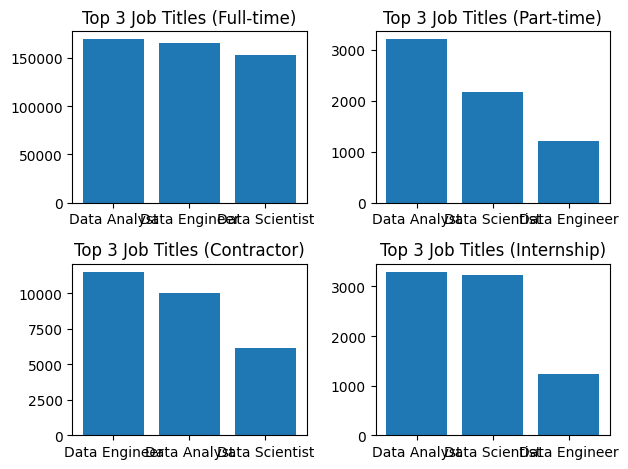

In [15]:
# Problem Statement:
# Create a subplot with 2 rows and 2 columns:

# In each subplot, plot a bar chart of the top 3 job titles by the number of job postings for each job schedule type 
# (Full-time, Part-time, Contractor, and Internship).
# Use fig.tight_layout() to adjust the spacing between subplots.

fig,ax=plt.subplots(2,2)

schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type'] == schedule]
    job_titles = df_schedule['job_title_short'].value_counts().head(3)
    ax[i//2, i%2].bar(job_titles.index, job_titles.values)
    ax[i//2, i%2].set_title(f'Top 3 Job Titles ({schedule})')

fig.tight_layout()
plt.show()


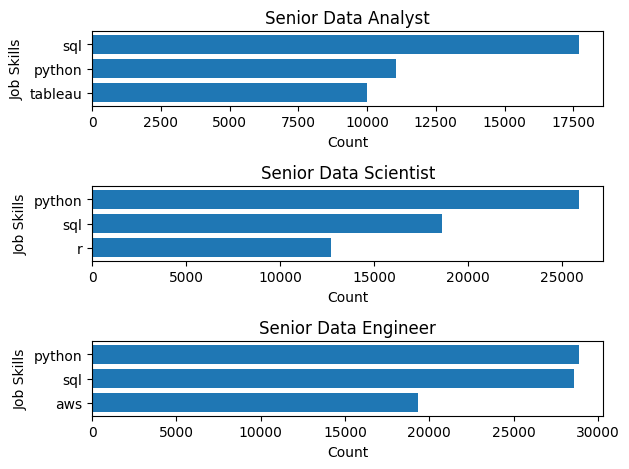

In [17]:
# Problem Statement:
# Create a subplot with 3 rows and 1 column:

# In each subplot, plot a horizontal bar chart of the top 3 job skills by the number of job postings for each job title (Senior Data Scientist, Senior Data Engineer, and Senior Data Analyst).
# Use fig.tight_layout() to adjust the spacing between subplots and invert_yaxis() to invert the y-axis in each subplot.
# Code Needed:
# job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
df_skills = df.explode('job_skills')
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
fig, ax = plt.subplots(len(job_roles), 1)
for i, role in enumerate(job_roles):
    role_skills = df_skills[df_skills['job_title_short'] == role]['job_skills'].value_counts().head(3)
    ax[i].barh(role_skills.index, role_skills.values)
    ax[i].set_title(role)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('Job Skills')
    ax[i].invert_yaxis()
fig.tight_layout()
plt.show()